### Carregando Libs

In [7]:
from ultralytics import YOLO

### Treinar modelo
- foi treinado com epochs de 100, 25, 12 e 1

In [34]:
# Carrega um modelo pré-treinado para classificação.
# "yolo11n-cls.pt" é:
# - yolo11: versão do modelo
# - n: nano (pequeno e rápido)
# - cls: modelo para classificação
# - .pt: arquivo com pesos pré-treinados
model = YOLO("yolo11n-cls.pt")

version = str("2")

# Inicia o treinamento
model.train(
    data="../dataset/clasificacao",   # pasta contendo train/ e val/
    epochs=1,        # número de épocas
    imgsz=128,        # redimensiona todas as imagens para 128x128
    batch=32,         # 32 imagens por lote
    #project="result_v" + version,   # pasta base para salvar resultados
    name="cat_or_dog_classificacao_v" + version,  # nome do experimento
)

New https://pypi.org/project/ultralytics/8.4.60 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.51  Python-3.14.5 torch-2.12.0+cpu CPU (13th Gen Intel Core i7-13700H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../dataset/clasificacao, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=128, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ca

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001F87512EAC0>
curves: []
curves_results: []
fitness: 0.8071428537368774
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.6142857074737549, 'metrics/accuracy_top5': 1.0, 'fitness': 0.8071428537368774}
save_dir: WindowsPath('C:/Users/mldantas/Documents/myCodes/gato_ou_cachorro/runs/classify/cat_or_dog_classificacao_v2-5')
speed: {'preprocess': 0.0009028571574682637, 'inference': 0.6517071428139128, 'loss': 1.714288373477757e-05, 'postprocess': 5.5714294181338376e-05}
top1: 0.6142857074737549
top5: 1.0

### verificar eficácia do modelo

In [35]:
from pathlib import Path
from collections import defaultdict
from ultralytics import YOLO
import pandas as pd

# ========= CONFIG =========
MODEL_PATH = "../runs/classify/cat_or_dog_classificacao_v2/weights/best.pt"
TEST_DIR = Path("../dataset/clasificacao/test")
BATCH_SIZE = 32

# extensões aceitas
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# ========= CARREGA MODELO =========
model = YOLO(MODEL_PATH)

# ========= COLETA IMAGENS =========
image_paths = []
true_labels = []

class_dirs = sorted([p for p in TEST_DIR.iterdir() if p.is_dir()])

for class_dir in class_dirs:
    for img_path in class_dir.rglob("*"):
        if img_path.is_file() and img_path.suffix.lower() in IMAGE_EXTS:
            image_paths.append(img_path)
            true_labels.append(class_dir.name)

if len(image_paths) == 0:
    raise ValueError(f"Nenhuma imagem encontrada em: {TEST_DIR}")

print(f"Total de imagens encontradas: {len(image_paths)}")
print("Classes encontradas na pasta test:", [d.name for d in class_dirs])

# ========= AVALIAÇÃO =========
rows = []
confusion = defaultdict(lambda: defaultdict(int))

for i in range(0, len(image_paths), BATCH_SIZE):
    batch_paths = image_paths[i:i+BATCH_SIZE]
    batch_true = true_labels[i:i+BATCH_SIZE]

    # inferência em lote
    results = model([str(p) for p in batch_paths], verbose=False)

    for img_path, true_label, result in zip(batch_paths, batch_true, results):
        # pega a classe prevista com maior probabilidade
        probs = result.probs.data
        pred_idx = int(probs.argmax().item())
        pred_label = result.names[pred_idx]
        confidence = float(probs[pred_idx].item())

        correct = pred_label == true_label
        confusion[true_label][pred_label] += 1

        rows.append({
            "arquivo": str(img_path),
            "classe_real": true_label,
            "classe_predita": pred_label,
            "confianca": confidence,
            "acertou": correct
        })

# ========= RESULTADOS =========
df = pd.DataFrame(rows)

accuracy = df["acertou"].mean() * 100
print(f"\nAcurácia geral no test: {accuracy:.2f}%")

# acurácia por classe
acc_por_classe = (
    df.groupby("classe_real")["acertou"]
      .mean()
      .mul(100)
      .sort_index()
      .rename("acuracia_%")
      .reset_index()
)

print("\nAcurácia por classe:")
display(acc_por_classe)

# matriz de confusão
classes = sorted(set(df["classe_real"]).union(set(df["classe_predita"])))
cm = pd.DataFrame(0, index=classes, columns=classes)

for real, preds in confusion.items():
    for pred, count in preds.items():
        cm.loc[real, pred] = count

print("\nMatriz de confusão (linhas = classe real, colunas = classe predita):")
display(cm)

# erros
# erros = df[~df["acertou"]].copy()
# print(f"\nQuantidade de erros: {len(erros)}")

# if len(erros) > 0:
#     print("\nExemplos de erros:")
#     display(erros.head(20))

# se quiser salvar relatório
# df.to_csv("avaliacao_test.csv", index=False)
# cm.to_csv("matriz_confusao_test.csv")

Total de imagens encontradas: 3140
Classes encontradas na pasta test: ['cachorro', 'gato']

Acurácia geral no test: 88.54%

Acurácia por classe:


,classe_real,acuracia_%
0,cachorro,92.866242
1,gato,84.203822



Matriz de confusão (linhas = classe real, colunas = classe predita):


,cachorro,gato
cachorro,1458,112
gato,248,1322


In [36]:
from pathlib import Path
from collections import defaultdict
from ultralytics import YOLO
import pandas as pd

# ========= CONFIG =========
MODEL_PATH = "../runs/classify/cat_or_dog_classificacao_v2-2/weights/best.pt"
TEST_DIR = Path("../dataset/clasificacao/test")
BATCH_SIZE = 32

# extensões aceitas
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# ========= CARREGA MODELO =========
model = YOLO(MODEL_PATH)

# ========= COLETA IMAGENS =========
image_paths = []
true_labels = []

class_dirs = sorted([p for p in TEST_DIR.iterdir() if p.is_dir()])

for class_dir in class_dirs:
    for img_path in class_dir.rglob("*"):
        if img_path.is_file() and img_path.suffix.lower() in IMAGE_EXTS:
            image_paths.append(img_path)
            true_labels.append(class_dir.name)

if len(image_paths) == 0:
    raise ValueError(f"Nenhuma imagem encontrada em: {TEST_DIR}")

print(f"Total de imagens encontradas: {len(image_paths)}")
print("Classes encontradas na pasta test:", [d.name for d in class_dirs])

# ========= AVALIAÇÃO =========
rows = []
confusion = defaultdict(lambda: defaultdict(int))

for i in range(0, len(image_paths), BATCH_SIZE):
    batch_paths = image_paths[i:i+BATCH_SIZE]
    batch_true = true_labels[i:i+BATCH_SIZE]

    # inferência em lote
    results = model([str(p) for p in batch_paths], verbose=False)

    for img_path, true_label, result in zip(batch_paths, batch_true, results):
        # pega a classe prevista com maior probabilidade
        probs = result.probs.data
        pred_idx = int(probs.argmax().item())
        pred_label = result.names[pred_idx]
        confidence = float(probs[pred_idx].item())

        correct = pred_label == true_label
        confusion[true_label][pred_label] += 1

        rows.append({
            "arquivo": str(img_path),
            "classe_real": true_label,
            "classe_predita": pred_label,
            "confianca": confidence,
            "acertou": correct
        })

# ========= RESULTADOS =========
df = pd.DataFrame(rows)

accuracy = df["acertou"].mean() * 100
print(f"\nAcurácia geral no test: {accuracy:.2f}%")

# acurácia por classe
acc_por_classe = (
    df.groupby("classe_real")["acertou"]
      .mean()
      .mul(100)
      .sort_index()
      .rename("acuracia_%")
      .reset_index()
)

print("\nAcurácia por classe:")
display(acc_por_classe)

# matriz de confusão
classes = sorted(set(df["classe_real"]).union(set(df["classe_predita"])))
cm = pd.DataFrame(0, index=classes, columns=classes)

for real, preds in confusion.items():
    for pred, count in preds.items():
        cm.loc[real, pred] = count

print("\nMatriz de confusão (linhas = classe real, colunas = classe predita):")
display(cm)

# erros
# erros = df[~df["acertou"]].copy()
# print(f"\nQuantidade de erros: {len(erros)}")

# if len(erros) > 0:
#     print("\nExemplos de erros:")
#     display(erros.head(20))

# se quiser salvar relatório
# df.to_csv("avaliacao_test.csv", index=False)
# cm.to_csv("matriz_confusao_test.csv")

Total de imagens encontradas: 3140
Classes encontradas na pasta test: ['cachorro', 'gato']

Acurácia geral no test: 89.04%

Acurácia por classe:


,classe_real,acuracia_%
0,cachorro,93.885350
1,gato,84.203822



Matriz de confusão (linhas = classe real, colunas = classe predita):


,cachorro,gato
cachorro,1474,96
gato,248,1322


In [37]:
from pathlib import Path
from collections import defaultdict
from ultralytics import YOLO
import pandas as pd

# ========= CONFIG =========
MODEL_PATH = "../runs/classify/cat_or_dog_classificacao_v2-3/weights/best.pt"
TEST_DIR = Path("../dataset/clasificacao/test")
BATCH_SIZE = 32

# extensões aceitas
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# ========= CARREGA MODELO =========
model = YOLO(MODEL_PATH)

# ========= COLETA IMAGENS =========
image_paths = []
true_labels = []

class_dirs = sorted([p for p in TEST_DIR.iterdir() if p.is_dir()])

for class_dir in class_dirs:
    for img_path in class_dir.rglob("*"):
        if img_path.is_file() and img_path.suffix.lower() in IMAGE_EXTS:
            image_paths.append(img_path)
            true_labels.append(class_dir.name)

if len(image_paths) == 0:
    raise ValueError(f"Nenhuma imagem encontrada em: {TEST_DIR}")

print(f"Total de imagens encontradas: {len(image_paths)}")
print("Classes encontradas na pasta test:", [d.name for d in class_dirs])

# ========= AVALIAÇÃO =========
rows = []
confusion = defaultdict(lambda: defaultdict(int))

for i in range(0, len(image_paths), BATCH_SIZE):
    batch_paths = image_paths[i:i+BATCH_SIZE]
    batch_true = true_labels[i:i+BATCH_SIZE]

    # inferência em lote
    results = model([str(p) for p in batch_paths], verbose=False)

    for img_path, true_label, result in zip(batch_paths, batch_true, results):
        # pega a classe prevista com maior probabilidade
        probs = result.probs.data
        pred_idx = int(probs.argmax().item())
        pred_label = result.names[pred_idx]
        confidence = float(probs[pred_idx].item())

        correct = pred_label == true_label
        confusion[true_label][pred_label] += 1

        rows.append({
            "arquivo": str(img_path),
            "classe_real": true_label,
            "classe_predita": pred_label,
            "confianca": confidence,
            "acertou": correct
        })

# ========= RESULTADOS =========
df = pd.DataFrame(rows)

accuracy = df["acertou"].mean() * 100
print(f"\nAcurácia geral no test: {accuracy:.2f}%")

# acurácia por classe
acc_por_classe = (
    df.groupby("classe_real")["acertou"]
      .mean()
      .mul(100)
      .sort_index()
      .rename("acuracia_%")
      .reset_index()
)

print("\nAcurácia por classe:")
display(acc_por_classe)

# matriz de confusão
classes = sorted(set(df["classe_real"]).union(set(df["classe_predita"])))
cm = pd.DataFrame(0, index=classes, columns=classes)

for real, preds in confusion.items():
    for pred, count in preds.items():
        cm.loc[real, pred] = count

print("\nMatriz de confusão (linhas = classe real, colunas = classe predita):")
display(cm)

# erros
# erros = df[~df["acertou"]].copy()
# print(f"\nQuantidade de erros: {len(erros)}")

# if len(erros) > 0:
#     print("\nExemplos de erros:")
#     display(erros.head(20))

# se quiser salvar relatório
# df.to_csv("avaliacao_test.csv", index=False)
# cm.to_csv("matriz_confusao_test.csv")

Total de imagens encontradas: 3140
Classes encontradas na pasta test: ['cachorro', 'gato']

Acurácia geral no test: 91.85%

Acurácia por classe:


,classe_real,acuracia_%
0,cachorro,93.439490
1,gato,90.254777



Matriz de confusão (linhas = classe real, colunas = classe predita):


,cachorro,gato
cachorro,1467,103
gato,153,1417


In [38]:
from pathlib import Path
from collections import defaultdict
from ultralytics import YOLO
import pandas as pd

# ========= CONFIG =========
MODEL_PATH = "../runs/classify/cat_or_dog_classificacao_v2-4/weights/best.pt"
TEST_DIR = Path("../dataset/clasificacao/test")
BATCH_SIZE = 32

# extensões aceitas
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# ========= CARREGA MODELO =========
model = YOLO(MODEL_PATH)

# ========= COLETA IMAGENS =========
image_paths = []
true_labels = []

class_dirs = sorted([p for p in TEST_DIR.iterdir() if p.is_dir()])

for class_dir in class_dirs:
    for img_path in class_dir.rglob("*"):
        if img_path.is_file() and img_path.suffix.lower() in IMAGE_EXTS:
            image_paths.append(img_path)
            true_labels.append(class_dir.name)

if len(image_paths) == 0:
    raise ValueError(f"Nenhuma imagem encontrada em: {TEST_DIR}")

print(f"Total de imagens encontradas: {len(image_paths)}")
print("Classes encontradas na pasta test:", [d.name for d in class_dirs])

# ========= AVALIAÇÃO =========
rows = []
confusion = defaultdict(lambda: defaultdict(int))

for i in range(0, len(image_paths), BATCH_SIZE):
    batch_paths = image_paths[i:i+BATCH_SIZE]
    batch_true = true_labels[i:i+BATCH_SIZE]

    # inferência em lote
    results = model([str(p) for p in batch_paths], verbose=False)

    for img_path, true_label, result in zip(batch_paths, batch_true, results):
        # pega a classe prevista com maior probabilidade
        probs = result.probs.data
        pred_idx = int(probs.argmax().item())
        pred_label = result.names[pred_idx]
        confidence = float(probs[pred_idx].item())

        correct = pred_label == true_label
        confusion[true_label][pred_label] += 1

        rows.append({
            "arquivo": str(img_path),
            "classe_real": true_label,
            "classe_predita": pred_label,
            "confianca": confidence,
            "acertou": correct
        })

# ========= RESULTADOS =========
df = pd.DataFrame(rows)

accuracy = df["acertou"].mean() * 100
print(f"\nAcurácia geral no test: {accuracy:.2f}%")

# acurácia por classe
acc_por_classe = (
    df.groupby("classe_real")["acertou"]
      .mean()
      .mul(100)
      .sort_index()
      .rename("acuracia_%")
      .reset_index()
)

print("\nAcurácia por classe:")
display(acc_por_classe)

# matriz de confusão
classes = sorted(set(df["classe_real"]).union(set(df["classe_predita"])))
cm = pd.DataFrame(0, index=classes, columns=classes)

for real, preds in confusion.items():
    for pred, count in preds.items():
        cm.loc[real, pred] = count

print("\nMatriz de confusão (linhas = classe real, colunas = classe predita):")
display(cm)

# erros
# erros = df[~df["acertou"]].copy()
# print(f"\nQuantidade de erros: {len(erros)}")

# if len(erros) > 0:
#     print("\nExemplos de erros:")
#     display(erros.head(20))

# se quiser salvar relatório
# df.to_csv("avaliacao_test.csv", index=False)
# cm.to_csv("matriz_confusao_test.csv")

Total de imagens encontradas: 3140
Classes encontradas na pasta test: ['cachorro', 'gato']

Acurácia geral no test: 70.61%

Acurácia por classe:


,classe_real,acuracia_%
0,cachorro,66.114650
1,gato,75.095541



Matriz de confusão (linhas = classe real, colunas = classe predita):


,cachorro,gato
cachorro,1038,532
gato,391,1179


### Teste com imagens aleatórias

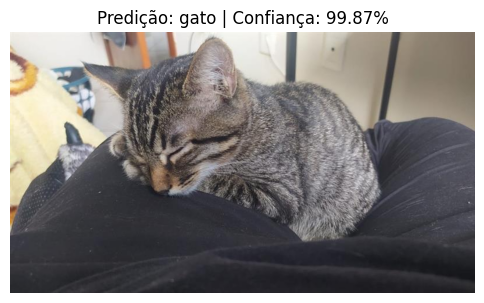

Probabilidades por classe:
cachorro: 0.13%
gato: 99.87%


In [56]:
%matplotlib inline

from PIL import Image
import matplotlib.pyplot as plt

model = YOLO("../runs/classify/cat_or_dog_classificacao_v2-3/weights/best.pt")

img_path = "../dataset/raw/lino_5.jpg"

def mostrar_predicao(image_path):
    results = model(image_path, verbose=False)
    result = results[0]

    probs = result.probs.data
    names = result.names

    pred_idx = int(probs.argmax().item())
    pred_label = names[pred_idx]
    confidence = float(probs[pred_idx].item())

    img = Image.open(image_path).convert("RGB")

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predição: {pred_label} | Confiança: {confidence*100:.2f}%")
    plt.show()

    print("Probabilidades por classe:")
    for i, p in enumerate(probs):
        print(f"{names[i]}: {float(p)*100:.2f}%")

# exemplo de uso
mostrar_predicao(img_path)